<table style="width:100%; border-bottom: 2px solid #ccc; margin-bottom: 20px;">
  <tr>
    <td style="vertical-align:middle;">
       <img src="../../resources/ADI-Logo-RGB-FullColor.png" alt="Company Logo" height="30">
    </td>
    <td style="text-align:right; vertical-align:middle;">
      <p style="margin: 0;">Phased Array Systems</p>
      <p style="font-size: 14px; margin: 0;">Iain Derrington – ADEF Group, ADI</p>
      <p style="font-size: 12px; color: #555;">Field Applications & Platform Engineer</p>
    </td>
  </tr>
</table>

## Phaser Calibration

As with all phased array systems, the **Phaser** requires calibration to achieve optimal performance.  
Calibration helps remove phase and gain mismatches between the individual antenna elements.

This script performs the following calibrations:

- **Channel calibration**: Channels **Rx0** and **Rx1** are used in the Phaser demo kit. Any differences between these two channels should be calibrated out.  
- **Element gain calibration**: Equalizes the gain response of each antenna element.  
- **Element phase calibration**: Corrects for phase offset between elements to ensure coherent beamforming.

## Basic Configuration


In [3]:
%matplotlib widget 
print("Running...")

try:
    import sys
    sys.path.insert(0, '../src')

    import os
    import time
    from pathlib import Path
    from time import sleep
    import matplotlib.pyplot as plt
    import git
    import numpy as np
    from adi import ad9361
    from adi.cn0566 import CN0566
    from scipy import signal
    import config_custom as config
    from phaser_functions import *
    from phaser_init import init_phaser_sdr
    
except Exception as ex:
    print(f"Failed to import all packages, check all dependacies are installed.\n\r {ex}")
    sys.exit(1)


plt.style.use('ggplot')
np.set_printoptions(legacy='1.25', precision=2)

phaser_root = get_phaser_root()
resource_path = phaser_root / "resources"
print(f"Resource path: {resource_path}")

SAMPLE_RATE = 30e6  # Sample rate for the SDR

try:
    print(f"Attempting to connect to R_Pi via ip:{config.RASP_IP_ADDRS}...")
    my_phaser = CN0566(uri="ip:" + config.RASP_IP_ADDRS)
    print(f"CN0566 Connected.")
except:
    print("Unable to connect to Phaser. Make sure it is connected and powered on.")
    sys.exit(1)

try:
    print(f"Attempting to connect to Pluto via ip:{config.PLUTO_IP_ADDRS}...")
    my_sdr = ad9361(uri="ip:" + config.PLUTO_IP_ADDRS)
    print(f"PlutoSDR connected.\n")
except:
    print("Unable to connect to Pluto. Make sure it is connected and powered on.")
    sys.exit(1)
    
    
my_phaser.sdr = my_sdr  # Set my_phaser.sdr
time.sleep(0.5)


# By default device_mode is "rx"
my_phaser.configure(device_mode="rx")
init_phaser_sdr(my_phaser, SAMPLE_RATE, config.rx_freq, 6, -6, 1024)
#my_phaser.load_channel_cal(filename=resource_path / "channel_cal_val.pkl")

"""
Set up receive freq uency. When using HB100, you need to know its frequency
fairly accurately. Use the cn0566_find_hb100.py script to measure its frequency
and write out to the cal file. IF using the onboard TX generator, delete
the cal file and set frequency via config.py or config_custom.py.
"""
try:
    my_phaser.signalFreq = load_hb100_cal(filename=resource_path / "hb100_freq_val.pkl")
    print(f"Found signal freq file \n\r fTx (Expected) = {my_phaser.signalFreq/1e9} GHz")
except:
    my_phaser.SignalFreq = config.SignalFreq
    print("No signal freq found, keeping at ", my_phaser.SignalFreq)
    print("And using TX path. Make sure antenna is connected.")

#  Configure SDR parameters.
my_sdr.filter = resource_path / "LTE20_MHz.ftr"  # Load LTE 20 MHz filter

# To disable tx, set attenuation to a high value and set frequency far from rx.
my_sdr.tx_hardwaregain_chan0 = int(-88)  # this is a negative number between 0 and -88
my_sdr.tx_hardwaregain_chan1 = int(-88)
my_sdr.tx_lo = int(1.0e9)                # Set TX LO to 1 GHz, far from RX frequency
    
"""
Configure CN0566 parameters.
ADF4159 and ADAR1000 array attributes are exposed directly, although normally
accessed through other methods.
"""
my_phaser.frequency = (int(my_phaser.signalFreq) + config.rx_freq) // 4  # PLL feedback via /4 VCO output
my_phaser.freq_dev_step = 5690
my_phaser.freq_dev_range = 0
my_phaser.freq_dev_time = 0
my_phaser.powerdown = 0
my_phaser.ramp_mode = "disabled"

print("\nComplete")


Running...
Resource path: C:\ADI Repo\PhaserTes\resources
Attempting to connect to R_Pi via ip:192.168.1.10...
CN0566 Connected.
Attempting to connect to Pluto via ip:192.168.2.1...
PlutoSDR connected.

Loaded filter: C:\ADI Repo\PhaserTes\beam-forming-tutorials\..\resources\LTE20_MHz.ftr
file not found, loading default 10.5GHz


AttributeError: module 'config_custom' has no attribute 'SignalFreq'

### SDR Channel Calibration

This step removes gain differences between the two SDR Rx channels.  
Each SDR Rx channel is connected—via an ADAR1000—to four elements of the antenna.

The channel calibration works by measuring the signal strength of each SDR channel independently and calculating the gain difference.

**The process consists of the following steps:**

- **Find the peak frequency bin:**
    - Set all ADAR1000 phase shifts to `0`.
    - Set all ADAR1000 gains to `127`.
    - Read the SDR Rx buffers (channels 0 and 1) and sum the data.
    - Take an FFT of the sum and identify the frequency bin with the maximum value.

----

- **Measure Pluto SDR signal strength for each channel independently:**
    - Set all gains on all channels to minimum.
    - Set gains on `Rx[0]` to `127`.
    - Read the Rx buffer.
    - Take an average power measurement and store it in `channel_levels[0]`.
    - Reset all ADAR1000 gains to `0`.
    - Set gains on `Rx[1]` to `127`.
    - Read the Rx buffer.
    - Take an average power measurement and store it in `channel_levels[1]`. </br>
----
- **Calculate gain mismatch:**
    - Compute the mismatch as:  
      `20 * log10(channel_levels[0] / channel_levels[1])`
    - Save the channel mismatch value to file. </br>


Running...
channel mismatch:  -0.8509410528248766  dB
Mean magnitude Ch0: 1.5217075083388103
Mean magnitude Ch1: 1.4311716481685548
ch0 gain: 7, ch1 gain: 6
Mean magnitude Ch0: 1.2880443903287002
Mean magnitude Ch1: 1.4670112489018377


C:\ADI Repo\Phaser\.venv3.12\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\ADI Repo\Phaser\.venv3.12\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


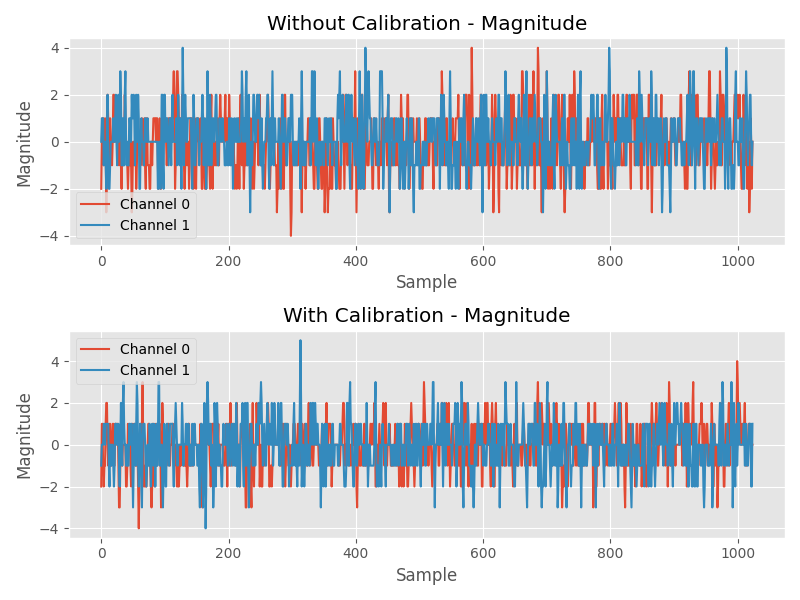


Complete


In [2]:
print("Running...")

peak_bin = find_peak_bin(my_phaser)

channel_levels, plot_data = measure_channel_gains(my_phaser, peak_bin, verbose=False)
ch_mismatch = 20.0 * np.log10(channel_levels[0] / channel_levels[1])

print("channel mismatch: ", ch_mismatch, " dB")
if ch_mismatch > 0:  # Channel 0 higher, boost ch1:
    my_phaser.ccal = [0.0, ch_mismatch]
else:  # Channel 1 higher, boost ch0:
    my_phaser.ccal = [-ch_mismatch, 0.0]

my_phaser.save_channel_cal(filename = resource_path / "channel_cal_val.pkl")

my_phaser.set_beam_phase_diff(0.0)

# Set ADAE1000 channel gains to max (127) for calibration
for channel in range(8):
    my_phaser.set_chan_gain( channel, 127, apply_cal=False ) # Set element to max

# Set the channel gains to 6 dB for calibration (starting point)
my_phaser.sdr.rx_hardwaregain_chan0 = 6 
my_phaser.sdr.rx_hardwaregain_chan1 = 6 

sleep(0.5)

#read the RX data before calibration
rx_data_uncal = my_phaser.sdr.rx()

print("Mean magnitude Ch0:", np.mean(np.abs(rx_data_uncal[0])))
print("Mean magnitude Ch1:", np.mean(np.abs(rx_data_uncal[1])))

my_phaser.sdr.rx_hardwaregain_chan0 = round(6 + my_phaser.ccal[0])
my_phaser.sdr.rx_hardwaregain_chan1 = round(6 + my_phaser.ccal[1])
sleep(0.5)

sdr_ch0_gain = my_phaser.sdr.rx_hardwaregain_chan0 
sdr_ch1_gain = my_phaser.sdr.rx_hardwaregain_chan1
print(f"ch0 gain: {sdr_ch0_gain}, ch1 gain: {sdr_ch1_gain}")

rx_data_cal = my_phaser.sdr.rx()


print("Mean magnitude Ch0:", np.mean(np.abs(rx_data_cal[0])))
print("Mean magnitude Ch1:", np.mean(np.abs(rx_data_cal[1])))

# Plot time-domain magnitudes and FFT
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Uncalibrated magnitude
ax[0].plot((rx_data_uncal[0]), label="Channel 0")
ax[0].plot((rx_data_uncal[1]), label="Channel 1")
ax[0].set_title("Without Calibration - Magnitude")
ax[0].set_xlabel("Sample")
ax[0].set_ylabel("Magnitude")
ax[0].legend()

# Calibrated magnitude
ax[1].plot(rx_data_cal[0], label="Channel 0")
ax[1].plot(rx_data_cal[1], label="Channel 1")
ax[1].set_title("With Calibration - Magnitude")
ax[1].set_xlabel("Sample")
ax[1].set_ylabel("Magnitude")
ax[1].legend()



plt.tight_layout()
plt.show()
print("\nComplete")

## Channel Gain Calibration

Next, we need to calibrate the gain stages of each individual antenna element.

### Steps:

- **Find the peak frequency bin**  
  *(same method as described in the Channel Calibration section)*
----
- **Measure the gain of each element (element[0:7]):**
    - Set all element gains to `0`.
    - Set the gain of the element of interest to `127`.
    - Read the SDR Rx buffers (channels 0 and 1).
    - Sum the data from both channels.
    - Compute the FFT and shift the DC component to the center.
    - Sum the FFT bins in a ±10 bin window around the peak frequency.
    - Calculate the average spectrum value and the peak magnitude.
----
- **Calculate gain calibration values**
    - Normalize or scale element responses relative to the strongest element (or average)
    - Save gain calibration values for later correction


Calibrating Gain, verbosely, then saving cal file...
Calibrating Element 0
measuring element:  0
Measured signal level (ADC counts): 0.24468223471907918
Calibrating Element 1
measuring element:  1
Measured signal level (ADC counts): 0.2697947125896601
Calibrating Element 2
measuring element:  2
Measured signal level (ADC counts): 0.2278389132170944
Calibrating Element 3
measuring element:  3
Measured signal level (ADC counts): 0.264256993231704
Calibrating Element 4
measuring element:  4
Measured signal level (ADC counts): 0.2472735158532031
Calibrating Element 5
measuring element:  5
Measured signal level (ADC counts): 0.2488734763751196
Calibrating Element 6
measuring element:  6
Measured signal level (ADC counts): 0.26206618058139675
Calibrating Element 7
measuring element:  7
Measured signal level (ADC counts): 0.23585518393047145
gcalibrated values:  [0.24468223471907918, 0.2697947125896601, 0.2278389132170944, 0.264256993231704, 0.2472735158532031, 0.2488734763751196, 0.262066180

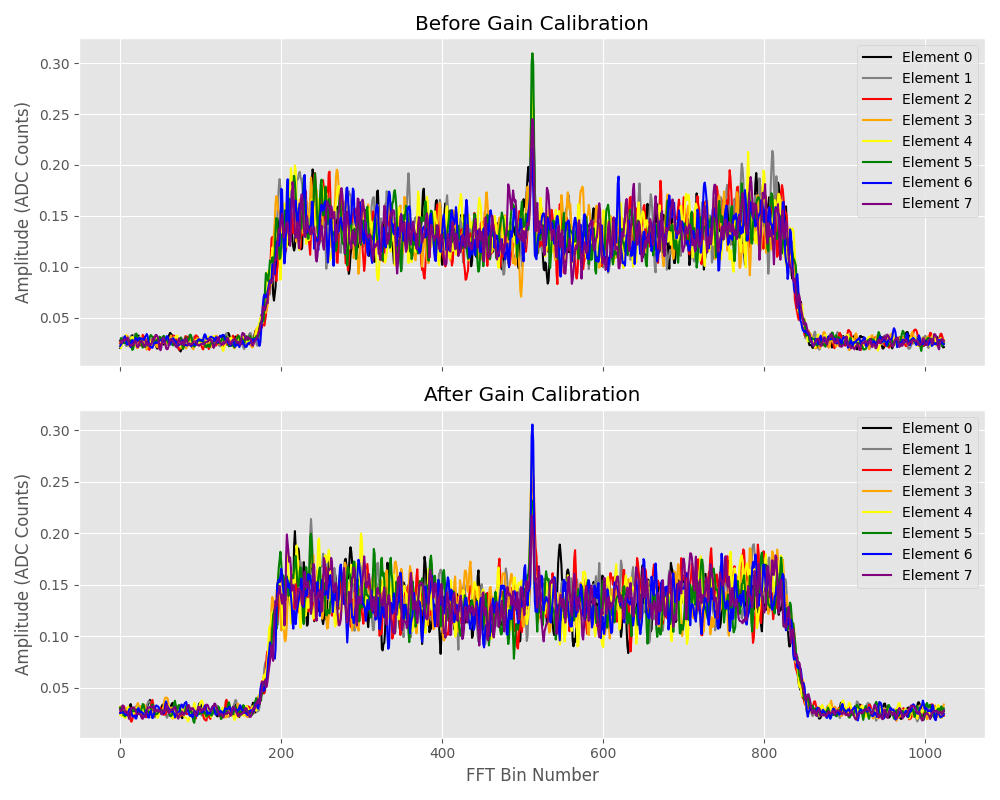

In [3]:
def measure_element_g( cn0566, cal, peak_bin, apply_cal=False):  # Default to central element
    """ 
        Calculate all the values required to do different plots. The method calls set_beam_phase_diff and
        sets the Phases of all channel. All the math is done here.
        parameters:
            gcal_element: type=int
                        If gain calibration is taking place, it indicates element number whose gain calibration is
                        is currently taking place
            cal_element: type=int
                        If Phase calibration is taking place, it indicates element number whose phase calibration is
                        is currently taking place
            peak_bin: type=int
                        Peak bin to examine around for amplitude
    """
    
    width = 10                                          # Bins around fundamental to sum
    
    cn0566.set_rx_hardwaregain(6)                       # SDR hardware gain set to 6dB (default). Both Rx Channels
    for i in range(8):                                  # Set all ADAR1000 gains to zero
        cn0566.set_chan_gain(i, 0, apply_cal=False)
    
    cn0566.set_chan_gain(cal, 127, apply_cal=apply_cal) # Set cal element gain to max
    
    sleep(1.0)  # todo - remove when driver fixed to compensate for ADAR1000 quirk
    
    print("measuring element: ", cal)
    
    total_sum = 0
    
    # win = np.blackman(cn0566.sdr.rx_buffer_size)
    win = signal.windows.flattop(cn0566.sdr.rx_buffer_size)
    win /= np.average(np.abs(win))  # Normalize to unity gain
    
    spectrum = np.zeros(cn0566.sdr.rx_buffer_size)

    for count in range(0, cn0566.Averages):  # repeatsnip loop and average the results
        _ = cn0566.sdr.rx()                  # todo - remove once confirmed no flushing necessary
        data = cn0566.sdr.rx()               # read a buffer of data
        y_sum = (data[0] + data[1]) * win

        s_sum = np.fft.fftshift(np.absolute(np.fft.fft(y_sum)))
        spectrum += s_sum

        # Look for peak value within window around fundamental (reject interferers)
        s_mag_sum = np.max(s_sum[peak_bin - width : peak_bin + width])
        total_sum += s_mag_sum

    # spectrum` is the average of all the FFTs, normalized by the number of averages and buffer size
    spectrum /= cn0566.Averages * cn0566.sdr.rx_buffer_size
    peakValue_sum = total_sum / (cn0566.Averages * cn0566.sdr.rx_buffer_size)

    return peakValue_sum, spectrum

print("Calibrating Gain, verbosely, then saving cal file...")
colors = ["black", "gray", "red", "orange", "yellow", "green", "blue", "purple"]

my_phaser.gain_cal = True       # Gain Calibration Flag
gcalibrated_values = []         # Intermediate cal values list
plot_data_pre = []
plot_data_post = []

for gcal_element in range(my_phaser.num_elements):
    print("Calibrating Element " + str(gcal_element))
    
    """
    gcal is the signal level
    spectrum is the normalised FFT of the received signal
    """
    gcal_val, spectrum = measure_element_g( my_phaser, gcal_element, peak_bin, apply_cal=False )
    
    print("Measured signal level (ADC counts): " + str(gcal_val))
   
    gcalibrated_values.append(gcal_val)     # make a list of intermediate cal values
    plot_data_pre.append(spectrum)


""" 
Minimum gain of intermediated cal val is set to maximum value as we cannot go beyond max value and gain
of all other channels are set accordingly
"""
print("gcalibrated values: ", gcalibrated_values)

for k in range(0, 8):
    my_phaser.gcal[k] = min(gcalibrated_values) / (gcalibrated_values[k])

# Reset the Gain calibration Flag once system gain is calibrated )
my_phaser.gain_cal = ( False )

# Save calibration
my_phaser.save_gain_cal(filename = resource_path / "gain_cal_val.pkl")  # Default filename

for gcal_element in range(my_phaser.num_elements):
    print("Calibrating Element " + str(gcal_element))
    
    """
    gcal is the signal level
    spectrum is the normalised FFT of the received signal
    """
    gcal_val, spectrum = measure_element_g( my_phaser, gcal_element, peak_bin, apply_cal=True )
    
    print("Measured signal level (ADC counts): " + str(gcal_val))
   
    gcalibrated_values.append(gcal_val)     # make a list of intermediate cal values
    plot_data_post.append(spectrum)


for ch in range(8):                                  # Set all ADAR1000 gains to zero
    my_phaser.set_chan_gain(ch, 127, apply_cal=True)
    
# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# BEFORE
ax1.set_title("Before Gain Calibration")
for i in range(my_phaser.num_elements):
    ax1.plot(plot_data_pre[i], color=colors[i % len(colors)], label=f"Element {i}")
ax1.set_ylabel("Amplitude (ADC Counts)")
ax1.legend()
ax1.grid(True)

# AFTER
ax2.set_title("After Gain Calibration")
for i in range(my_phaser.num_elements):
    ax2.plot(plot_data_post[i], color=colors[i % len(colors)], label=f"Element {i}")
ax2.set_xlabel("FFT Bin Number")
ax2.set_ylabel("Amplitude (ADC Counts)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Channel Phase Calibration

This step aligns the relative phase of each antenna element with a reference element to ensure coherent beamforming.

### Procedure:

- **Find the peak frequency bin**  
  *(same method as in previous calibration steps)*
----
- **Clear existing calibrations**
----
- **Iterate through each element:**
    - Set all element gains to `0`.
    - Set the **reference element** gain to `127`.
    - Set the **calibration element** gain to `127`.
    - Set the phase of the reference element to `0`.
    - **Sweep phase angles** for the calibration element from `-180°` to `+180°` in steps of `2.8125°`:
        - Set the calibration element phase.
        - Read the SDR Rx buffers (both channels).
        - Perform FFT on the received signal.
        - Measure the amplitude of the peak bin.
        - Append peak value to a list for that element.
----
- **Update the phase calibration**
    - Determine the phase value that maximizes the signal.
    - Store the optimal phase correction for each element.


Calibrating Phase, verbosely, then saving cal file...
Peak bin at  534  out of  1024
Calibrating Element 0
Null found at  157.5
Phase Delta to correct:  22.5
Calibrating Element 1
Null found at  151.875
Phase Delta to correct:  28.125
Calibrating Element 2
Null found at  163.125
Phase Delta to correct:  16.875
Calibrating Element 3
Null found at  -70.3125
Phase Delta to correct:  -109.6875
Calibrating Element 4
Null found at  177.1875
Phase Delta to correct:  2.8125
Calibrating Element 5
Null found at  -151.875
Phase Delta to correct:  -28.125
Calibrating Element 6
Null found at  -146.25
Phase Delta to correct:  -33.75


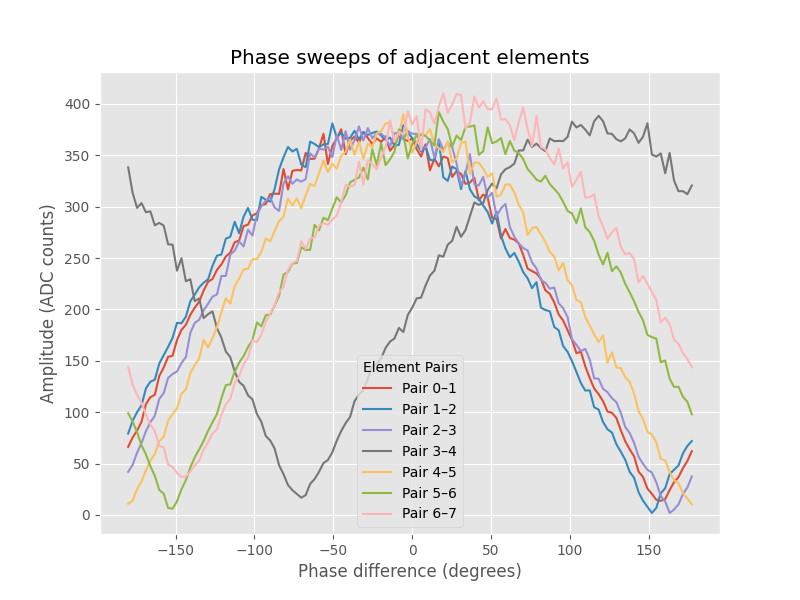

Done calibration


In [5]:
print("Calibrating Phase, verbosely, then saving cal file...")

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

phaseAngles, signalGain = phase_calibration(my_phaser, verbose=True)  # Start Phase Calibration
my_phaser.save_phase_cal(filename=resource_path / "phase_cal_val.pkl")  

plt.title("Phase sweeps of adjacent elements")
plt.xlabel("Phase difference (degrees)")
plt.ylabel("Amplitude (ADC counts)")

for i in range(0, 7):
    plt.plot(phaseAngles, signalGain[i], label=f"Pair {i}–{i+1}")

plt.legend(title="Element Pairs")
plt.show()

my_phaser.set_beam_phase_diff(0)
my_phaser.set_rx_hardwaregain(6)
my_phaser.set_all_gain(127)

print("Done calibration")
